# Project: Harry Potter characters

***What is the ideas/ goals***

Inspired by the examples of proposed graph on the github page of the class, we realized that we all in the group really likes the Harry Potter uniververse. We though it was interessant to study a graph representing all the characters of Harry Potter, to better understand the role and importance in the story, as well as how close each characters are from eachother. We also wanted to have an inside track on which type of characters are each of them and if we can regroup them in logical groups that have sense with their characteristics.

***What is the network we will be analyzing***

To acheive this goal, we have decided to build and analyse a network composed of (almost) all charcaters of the Wizarding World, each one having one node. 

***What is the text you will be analyzing***

We have also decided to associates the wiki text from the Harry Potter wiki fandom page (https://harrypotter.fandom.com) of the correspondig character to each node. This means, for each node, the name of the node enables us to retreive the text of its wikipage.

***How will you tie networks and text together in your paper?***

Then, we add one edge from one character to another if there is a clickable link on its wikipage that link to another characters' wikipage. We will also try to analyse more specificly these wikitexts to extract interessting most used words and vocabullary to understand the distance between the different nodes and the possibles strongly connected subgroups in the graphs.

***how did we dowload our data and create our network***

* First we have looked for the most complete and large list of Harry Potter character we could find online (https://beyondhogwarts.com/harry-potter/books/character-list/)
* Then, manually we have constructed the txt file containing the list of all characters. We took all the chracters of this online list and checked what was the title of its corresponding fandom wiki page (https://harrypotter.fandom.com/wiki/{name}).
* In another notebook, we go through every names in this list and for each character we open the associated fandom wiki page's wikitext and create a local file to store the wikitext in a .txt file.
* To have all the wikitext accessible simply (without creating all the local files everytime), we pushed all the wikitext files as well as the hole list of characters name on our public github (https://github.com/EricBrevilliers/Harry_Potter_Graph)
* In the next cell, we go through the list of names on github to retrieve a list of character names.

In [1]:
# Go through the list of names on github to retrieve a list of character names
import urllib.request
import requests

# Read the file with the wikitext of the harry_Potter_characters list and extract the names
url_list = f"https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/list_characters/harry_Potter_characters.txt"

response_list = requests.get(url_list)
names = [] # Initialize the list

if response_list.status_code == 200:
    content_list = response_list.text
    # We divide the string "content_list" in a list (one string/name per line)
    names = content_list.splitlines()
    
    # Ensure that there is no empty name
    names = [name for name in names if name.strip()]
    print(f"Found {len(names)} names. The first 5: {names[:5]}")
else:
    print(f"Error retrieving file: {response_list.status_code}")

Found 412 names. The first 5: ['Hannah_Abbott', 'Euan_Abercrombie', 'Stewart_Ackerley', 'Cornelius_Agrippa', 'Arkie_Alderton']


* In the next cell, we go through every characters previously added in the list and make each of them being a node. For all the characters we also search in the github the associated wikitext and use it to add a ***word_count* attribute** to each node and to add the edges.

In [2]:
# Go through every wikitext we have already saved in our github and construct the graph

import requests
import networkx as nx
import re

HpGraph = nx.DiGraph()

name_set = set(names)

print(f"Building graph from {len(names)} characters...")

for name in name_set:
    url = f"https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/wikitext_files/{name.replace('%27', '%2527')}.txt"
    
    response = requests.get(url)
    
    if response.status_code == 200:
        content = response.text
    
        # Adds the node and the word_count attribute
        words = re.findall(r'\b\w+\b', content)
        word_count = len(words)
        HpGraph.add_node(name.replace('_', ' ').replace('%27', "'"), word_count=word_count)

        # Finds everything between [[ and the first |, #, or ]
        links = re.findall(r'\[\[([^\]\|#]+)', content)

        # Loop over all found links
        for link in links:
            # Filter to ignore 'File:', 'Category:', 'Image:', etc.
            if ':' in link:
                continue
            
            normalized_link = link.strip().replace(' ', '_').replace("'", "%27")
            
            # We check if the normalized link is in our 'name_set'
            if normalized_link in name_set:
                # Avoid a node pointing to itself
                if name != normalized_link:
                    HpGraph.add_edge(name.replace('_', ' ').replace('%27', "'"), link)
    else:
        # It's normal to have some errors if a file was not
        # correctly saved or if the name has a typo
        print(f"[Warning] Failed to load: {name} (Status: {response.status_code})")

print(f"Graph construction complete. {HpGraph.number_of_nodes()} nodes added, {HpGraph.number_of_edges()} edges created.")

Building graph from 412 characters...
Graph construction complete. 412 nodes added, 6928 edges created.


* In the next cell we print the size of the retrieved networks (in nodes) and the list of all nodes, just to have an idea of the graph

In [3]:
print(len(HpGraph.nodes()))
print(HpGraph.nodes())

412
['Terry Boot', 'Hermione Granger', 'Harry Potter', 'Michael Corner', 'Anthony Goldstein', 'Salazar Slytherin', 'Padma Patil', 'Ronald Weasley', 'Gilderoy Lockhart', 'Dolores Umbridge', 'Lucius Malfoy', 'Draco Malfoy', 'Vincent Crabbe', 'Gregory Goyle', 'Horace Slughorn', 'Severus Snape', 'Albus Dumbledore', 'Minerva McGonagall', 'Tom Riddle', 'Neville Longbottom', 'Trevor', 'Cho Chang', 'Bane', 'Firenze', 'Rubeus Hagrid', 'Grawp', 'Albus Potter', 'Theodore Nott', 'Nott', 'Blaise Zabini', 'Scorpius Malfoy', 'Dean Thomas', 'Marcus Belby', 'Pius Thicknesse', 'Rufus Scrimgeour', 'Kingsley Shacklebolt', 'Corban Yaxley', 'Amelia Bones', 'Antonin Dolohov', 'Lily Potter (I)', 'Alastor Moody', 'Albert Runcorn', 'Travers', 'Selwyn', 'Amycus Carrow', 'Arthur Weasley', 'Xenophilius Lovegood', 'Luna Lovegood', 'Percy Weasley', 'Fred Weasley', 'Sirius Black', 'Stubby Boardman', 'Walburga Black', 'Regulus Black', 'Alphard Black', 'Bellatrix Lestrange', 'Andromeda Tonks', 'Narcissa Malfoy', 'James

* In the next cell we filter the newtowrk node to remove the isolated nodes

In [4]:
# Identify isolated nodes and remove them
nodes_to_remove = []
for node in HpGraph.nodes():
    if HpGraph.in_degree(node) == 0 and HpGraph.out_degree(node) == 0:
        nodes_to_remove.append(node)
        
HpGraph_noIsolatedNodes = HpGraph.copy()
HpGraph_noIsolatedNodes.remove_nodes_from(nodes_to_remove)
print(f"{len(nodes_to_remove)} isolated nodes deleted. {HpGraph_noIsolatedNodes.number_of_nodes()} nodes still in network.")

21 isolated nodes deleted. 391 nodes still in network.


* In the next cell we filter the network to only keep the larger connected component

In [5]:
# Finds the connected component and keeps the largest
weakly_connected_components = list(nx.weakly_connected_components(HpGraph))

if weakly_connected_components:
    largest_component = max(weakly_connected_components, key=len)
    HpGraph_connected = HpGraph.subgraph(largest_component).copy()
else:
    HpGraph_connected = HpGraph.copy()

print(f"Largest connected component contains {HpGraph_connected.number_of_nodes()} nodes")

Largest connected component contains 387 nodes


### Total size of the text data

**Question:** What is the total size of our text data (in total number of words and in megabytes) for all Harry Potter character pages that appear in the largest connected component of the network?

In the next cell, we use the `word_count` attribute stored on each node and the raw wikitext files to estimate how large our corpus is.

In [6]:
# Total number of words in all character pages in the largest connected component

# Extract the "word_count" attribute for nodes in HpGraph_connected
word_counts = nx.get_node_attributes(HpGraph_connected, "word_count")

total_words = sum(word_counts.values())

print(f"Total number of words in all character pages: {total_words:,d}")


Total number of words in all character pages: 1,592,520


### Total size of the text data in megabytes

**Question:**  
How large is our corpus in terms of file size (MB)?

In the next cell, we approximate the total size of all wikitext files by summing the number of bytes downloaded for each character in the largest connected component. We then convert this total to megabytes.


In [7]:
import requests

total_bytes = 0

print(f"Calculating total file size for {HpGraph_connected.number_of_nodes()} nodes...")

for name in HpGraph_connected.nodes():
    
    base_filename = name.replace(" ", "_").replace("'", "%27")
    
    url_filename = base_filename.replace('%27', '%2527')
    
    # This URL now correctly points to the file on GitHub
    url = f"https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/wikitext_files/{url_filename}.txt"
    
    try:
        response = requests.get(url)
        if response.status_code == 200:
            total_bytes += len(response.content)
    except requests.exceptions.RequestException as e:
        print(f"Warning: Could not fetch {name}")

# Convert bytes to megabytes (using the 1024*1024 )
total_mb = total_bytes / (1024 * 1024)

print(f"\n--- Total File Size (for {HpGraph_connected.number_of_nodes()} nodes) ---")
print(f"Total Bytes: {total_bytes:,d}")
# Format to 4 decimal
print(f"Total Megabytes (MB): {total_mb:.4f} MB")

Calculating total file size for 387 nodes...

--- Total File Size (for 387 nodes) ---
Total Bytes: 9,946,601
Total Megabytes (MB): 9.4858 MB


### Summary: Total size of the text data

Our final dataset (the largest connected component of the network) contains:

- **Total text:** 1,592,520 words  
- **Total file size:** approximately 9.486 MB  
- **Number of characters (nodes):** 387  

This text corpus will be used in the remainder of our analysis, both for network–text comparisons and for extracting semantic information from character pages.

### Basic Network Information

**Question:**  
What are the basic structural properties of our final network (`HpGraph_connected`)?

In this section, we compute the most fundamental characteristics of the graph, including:
- The total number of nodes (characters)  
- The total number of edges (links between characters)  
- The density of the directed network  

These metrics provide a first overview of how connected the Harry Potter character graph is.


In [8]:
# Basic Network Statistics: nodes, edges, density

# Get the number of nodes and edges
num_nodes = HpGraph_connected.number_of_nodes()
num_edges = HpGraph_connected.number_of_edges()

print("--- Basic Network Stats ---")
print(f"Nodes (Characters): {num_nodes}")
print(f"Edges (Links): {num_edges}")

# Density of a directed graph: edges / (N*(N-1))
# Calculate density, rounding to 4 decimals
if num_nodes > 1:
    max_possible_edges = num_nodes * (num_nodes - 1)
    density = num_edges / max_possible_edges
    print(f"Density: {density:.4f}")
else:
    print("Density: N/A")


--- Basic Network Stats ---
Nodes (Characters): 387
Edges (Links): 6924
Density: 0.0464


### Degree Statistics



**Question:** How are characters connected in the network in terms of incoming and outgoing links?



To gain a deeper understanding of the structure of the Harry Potter character graph, we now compute:



- The **average in-degree** (how many characters link *to* a character)  

- The **average out-degree** (how many characters a character links *to*)  

- The **maximum in-degree**, and which character(s) receive the most links  

- The **maximum out-degree**, and which character(s) create the most links  



These metrics highlight the most central and influential characters in the network based on direct hyperlink connections.


In [9]:
#Compute in-degree and out-degree statistics

# Get dictionaries of degrees {node: degree}
in_degrees_dict = dict(HpGraph_connected.in_degree())
out_degrees_dict = dict(HpGraph_connected.out_degree())

# Calculate averages
avg_in = sum(in_degrees_dict.values()) / num_nodes
avg_out = sum(out_degrees_dict.values()) / num_nodes  # Note: avg_in and avg_out must be equal

# Find max values
max_in = max(in_degrees_dict.values())
max_out = max(out_degrees_dict.values())

# Find the characters with those max values
max_in_nodes = [node for node, deg in in_degrees_dict.items() if deg == max_in]
max_out_nodes = [node for node, deg in out_degrees_dict.items() if deg == max_out]

print(f"--- Degree Statistics ---")
print(f"Average in-degree: {avg_in:.4f}")
print(f"Average out-degree: {avg_out:.4f}")

print(f"\nMaximum in-degree: {max_in}")
print(f"Character(s) with maximum in-degree:")
for node in max_in_nodes:
    print(f"  - {node}")

print(f"\nMaximum out-degree: {max_out}")
print(f"Character(s) with maximum out-degree:")
for node in max_out_nodes:
    print(f"  - {node}")


--- Degree Statistics ---
Average in-degree: 17.8915
Average out-degree: 17.8915

Maximum in-degree: 280
Character(s) with maximum in-degree:
  - Harry Potter

Maximum out-degree: 168
Character(s) with maximum out-degree:
  - Harry Potter


### Summary of Degree Statistics

The average in-degree and out-degree are both 17.8915, meaning a typical character page links to (or is linked by) about 18 other characters. This equality is expected in a directed graph.

Unsurprisingly, the character with the highest in-degree (280 links received) and the highest out-degree (168 links made) is **Harry Potter**, confirming his central role. His page is the most referenced, and it also links out to the widest range of other characters, making him the most structurally central node in the network.

###  Top 5 Most Central Characters

**Question:**  
Who are the Top 5 most central characters by in-degree and out-degree?

While Harry Potter is clearly the most central character, we can learn much more about the network by identifying the next most important nodes.

- **Top 5 In-Degree:** Characters who are mentioned or linked to most often.  
  This reflects "importance" in the Harry Potter universe.

- **Top 5 Out-Degree:** Characters whose pages link out to the most other characters.  
  These are “hub” pages rich with connections.


In [10]:
import pandas as pd

# Sort nodes by in-degree and out-degree
sorted_in = sorted(in_degrees_dict.items(), key=lambda x: x[1], reverse=True)
sorted_out = sorted(out_degrees_dict.items(), key=lambda x: x[1], reverse=True)

# Get the Top 5 of each
top5_in = sorted_in[:5]
top5_out = sorted_out[:5]

# Convert to DataFrames for clean display
df_top_in = pd.DataFrame(top5_in, columns=["Character", "In-Degree"])
df_top_out = pd.DataFrame(top5_out, columns=["Character", "Out-Degree"])

print("--- Top 5 Characters by In-Degree ---")
display(df_top_in)

print("\n--- Top 5 Characters by Out-Degree ---")
display(df_top_out)


--- Top 5 Characters by In-Degree ---


,Character,In-Degree
0,Harry Potter,280
1,Tom Riddle,226
2,Albus Dumbledore,185
3,Ronald Weasley,181
4,Hermione Granger,177



--- Top 5 Characters by Out-Degree ---


,Character,Out-Degree
0,Harry Potter,168
1,Albus Dumbledore,146
2,Ronald Weasley,133
3,Hermione Granger,118
4,Tom Riddle,112


**Summary of Top 5 Most Central Characters**

The Top 5 characters by **in-degree** are:

1. Harry Potter  
2. Tom Riddle  
3. Albus Dumbledore  
4. Ronald Weasley  
5. Hermione Granger  

These are the most frequently referenced characters across the wiki, which matches their narrative importance in the Harry Potter universe.

The Top 5 characters by **out-degree** are:

1. Harry Potter  
2. Albus Dumbledore  
3. Ronald Weasley  
4. Hermione Granger  
5. Tom Riddle  

These pages link out to many other characters, acting as “hubs” that connect multiple storylines.  
Overall, this ranking confirms that the main trio (Harry, Ron, Hermione), together with Dumbledore and Tom Riddle/Voldemort, form the structural core of the character network.


### Degree Distributions

**Question:**  
What do the in-degree and out-degree distributions look like in our Harry Potter character network?

In the next cell we plot the distributions of in-degrees and out-degrees to understand how common highly connected characters are.  
These plots help reveal whether the network has a heavy-tailed structure (a few very connected characters and many with few links), which is typical for real-world hyperlink networks.


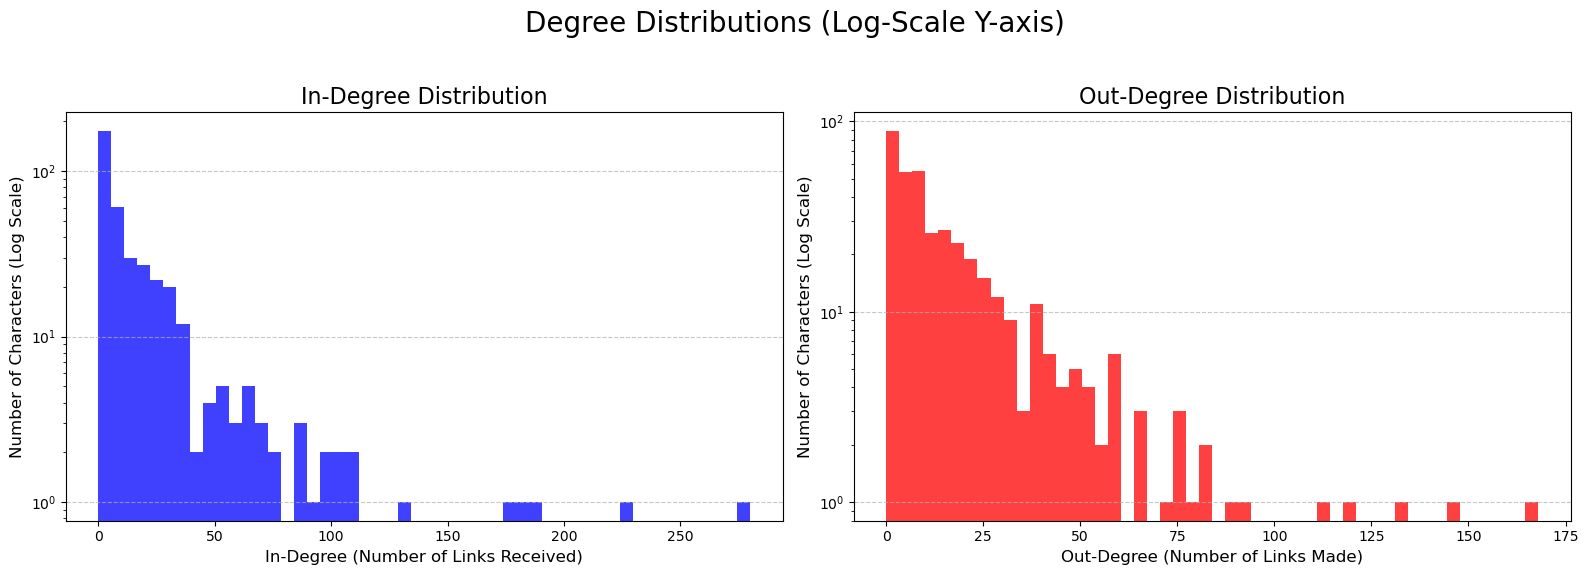

In [11]:
import matplotlib.pyplot as plt

# We already have the degree dictionaries from the previous cells
# in_degrees_dict = dict(HpGraph_connected.in_degree())
# out_degrees_dict = dict(HpGraph_connected.out_degree())

# Get just the degree values for plotting
in_degree_values = list(in_degrees_dict.values())
out_degree_values = list(out_degrees_dict.values())

# Create a figure with two subplots, side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: In-Degree Distribution ---
ax1.hist(in_degree_values, bins=50, alpha=0.75, color='b')
ax1.set_title('In-Degree Distribution', fontsize=16)
ax1.set_xlabel('In-Degree (Number of Links Received)', fontsize=12)
ax1.set_ylabel('Number of Characters (Log Scale)', fontsize=12)
ax1.set_yscale('log') # Use log scale as requested
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: Out-Degree Distribution ---
ax2.hist(out_degree_values, bins=50, alpha=0.75, color='r') 
ax2.set_title('Out-Degree Distribution', fontsize=16)
ax2.set_xlabel('Out-Degree (Number of Links Made)', fontsize=12)
ax2.set_ylabel('Number of Characters (Log Scale)', fontsize=12)
ax2.set_yscale('log') # Use log scale
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Degree Distributions (Log-Scale Y-axis)', fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

### Figure 1: Degree Distributions

These histograms show the in-degree (left, blue) and out-degree (right, orange) for our 387-node network. The y-axis is on a log scale to better visualize the long tail.

Both plots show a clear **heavy-tailed distribution**, which is typical for real-world networks. This confirms our earlier finding:
* A vast majority of characters have a very low degree (they are "peripheral" characters).
* A "long tail" of a few, highly-connected nodes (like Harry Potter, Dumbledore, etc.) have a very high degree.


### Path Length and Network Diameter

**Question:** How "far" apart are characters in the network?

To understand how quickly information (or a click) can get from one character to any other, we now compute:
* The **average shortest path length**: The average number of clicks it takes to get from any character to any other.
* The **diameter**: The *longest* shortest path between any two characters in the network.

These metrics help us understand how tightly connected the network is. A low average path length (like in a "small-world" network) means it's very easy to navigate.

In [12]:
# Calculate shortest path and diameter

print(f"Calculating shortest path metrics for {num_nodes} nodes...")
print("This may take a few minutes, please be patient.")

try:
    # 1. Calculate Average Shortest Path Length
    # This runs a BFS from every node, so it's computationally intensive
    avg_path_length = nx.average_shortest_path_length(HpGraph_connected)
    
    # 2. Calculate Diameter
    # The diameter is the longest of all the shortest paths
    diameter = nx.diameter(HpGraph_connected)

    print(f"\n--- Network Path Stats (Directed) ---")
    print(f"Average Shortest Path Length: {avg_path_length:.4f}")
    print(f"Network Diameter: {diameter}")

except nx.NetworkXError as e:
    print(f"\nError: {e}")
    print("The directed graph is not strongly connected (you can't get from every node to every other node).")
    print("This is normal. We will calculate these metrics on the UNDIRECTED version instead.")
    
    # Fallback to undirected graph, which we know is connected
    G_undirected = HpGraph_connected.to_undirected()
    
    # 1. Calculate Average Shortest Path Length on the undirected graph
    avg_path_length_ud = nx.average_shortest_path_length(G_undirected)
    
    # 2. Calculate Diameter on the undirected graph
    diameter_ud = nx.diameter(G_undirected)
    
    print(f"\n--- Network Path Stats (Undirected) ---")
    print(f"Average Shortest Path Length (Undirected): {avg_path_length_ud:.4f}")
    print(f"Network Diameter (Undirected): {diameter_ud}")

Calculating shortest path metrics for 387 nodes...
This may take a few minutes, please be patient.

Error: Graph is not strongly connected.
The directed graph is not strongly connected (you can't get from every node to every other node).
This is normal. We will calculate these metrics on the UNDIRECTED version instead.

--- Network Path Stats (Undirected) ---
Average Shortest Path Length (Undirected): 2.2245
Network Diameter (Undirected): 6


### Summary of Path Length and Diameter

Because the directed graph is not strongly connected, we computed the path-based metrics on the undirected version of the network.  
The results show that:

- The **average shortest path length** is approximately **2.22**, meaning that any character can typically be reached from any other in just a little over two steps.
- The **diameter** of the network is **6**, which is the longest shortest-path distance between any two characters.

Given the size of the graph (387 characters), these values are very small.  
This confirms that the Harry Potter character network exhibits clear **small-world properties**: most characters are only a few steps apart, and the entire network is highly navigable.

### Clustering Coefficient

**Question:**  
How "cliquey" is the Harry Potter character network?

To complete our small-world analysis, we compute the clustering coefficient.  
This measures how likely it is that two characters who are both connected to a third character are also connected to each other (i.e., **"are the friends of my friends also friends?"**).

A high clustering coefficient, **combined with the low average path length** we computed earlier, is the key indicator of a *small-world network*.

We will compute:
- The **average clustering coefficient** (average of all nodes' local clustering)
- The **global clustering coefficient** (also called transitivity)


In [13]:
# Compute clustering coefficients

import networkx as nx

# Convert to undirected graph because clustering is defined for undirected networks
G_und = HpGraph_connected.to_undirected()

# Compute clustering metrics
avg_clustering = nx.average_clustering(G_und)
global_clustering = nx.transitivity(G_und)

print("--- Clustering Coefficients ---")
print(f"Average clustering coefficient: {avg_clustering:.4f}")
print(f"Global clustering coefficient (transitivity): {global_clustering:.4f}")


--- Clustering Coefficients ---
Average clustering coefficient: 0.6327
Global clustering coefficient (transitivity): 0.3206


### Summary of Clustering

The results are:

* **Average Clustering Coefficient: 0.6327**
* **Global Clustering Coefficient: 0.3206**

These are very high values. A clustering coefficient of 0.63 means that if a character is connected to two other characters, there is a **63% chance** that those two characters are also connected to each other.

**Conclusion: Small-World Network**

This finding is the final piece of our analysis:

1. **High Clustering (0.6327):** The network is highly "cliquey" and full of tight-knit groups.  
2. **Low Average Path Length (2.22):** The network is still very easy to navigate.

This combination of **high clustering** and **low path length** is the classic definition of a **small-world network**.  
Our analysis confirms that the Harry Potter character wiki has this distinct and important structure.


## Network Visualization

**Question:** What does the overall structure of the network look like?

To conclude our analysis, we visualize the undirected version of the network.

Each node represents a character, and an edge connects two characters if their pages link to each other.
We use a `spring_layout`, which places highly interconnected groups closer together and pushes less connected nodes outward.

This allows us to visually confirm characteristics such as:
* The presence of central hubs (Harry, Dumbledore, etc.)
* The grouping of characters into communities
* The overall small-world structure

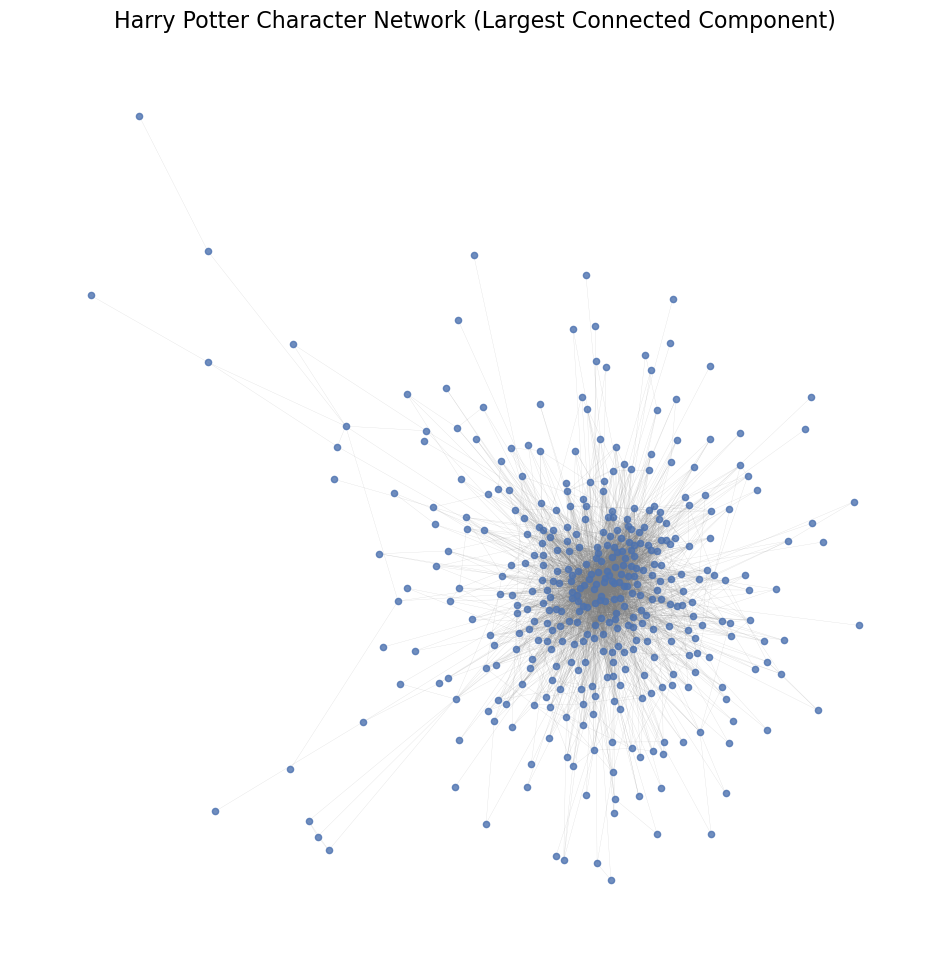

In [14]:
# 3. Network Visualization (Undirected)

import matplotlib.pyplot as plt
import networkx as nx

# Convert to undirected for visualization
G_und = HpGraph_connected.to_undirected()

# Use a spring layout for community-like grouping
plt.figure(figsize=(12, 12))

pos = nx.spring_layout(G_und, seed=42, k=0.15)  # k controls spacing

# Draw nodes
nx.draw_networkx_nodes(
    G_und,
    pos,
    node_size=20,
    node_color="#4C72B0",
    alpha=0.8
)

# Draw edges
nx.draw_networkx_edges(
    G_und,
    pos,
    width=0.2,
    alpha=0.3,
    edge_color="gray"
)

plt.title("Harry Potter Character Network (Largest Connected Component)", fontsize=16)
plt.axis("off")
plt.show()


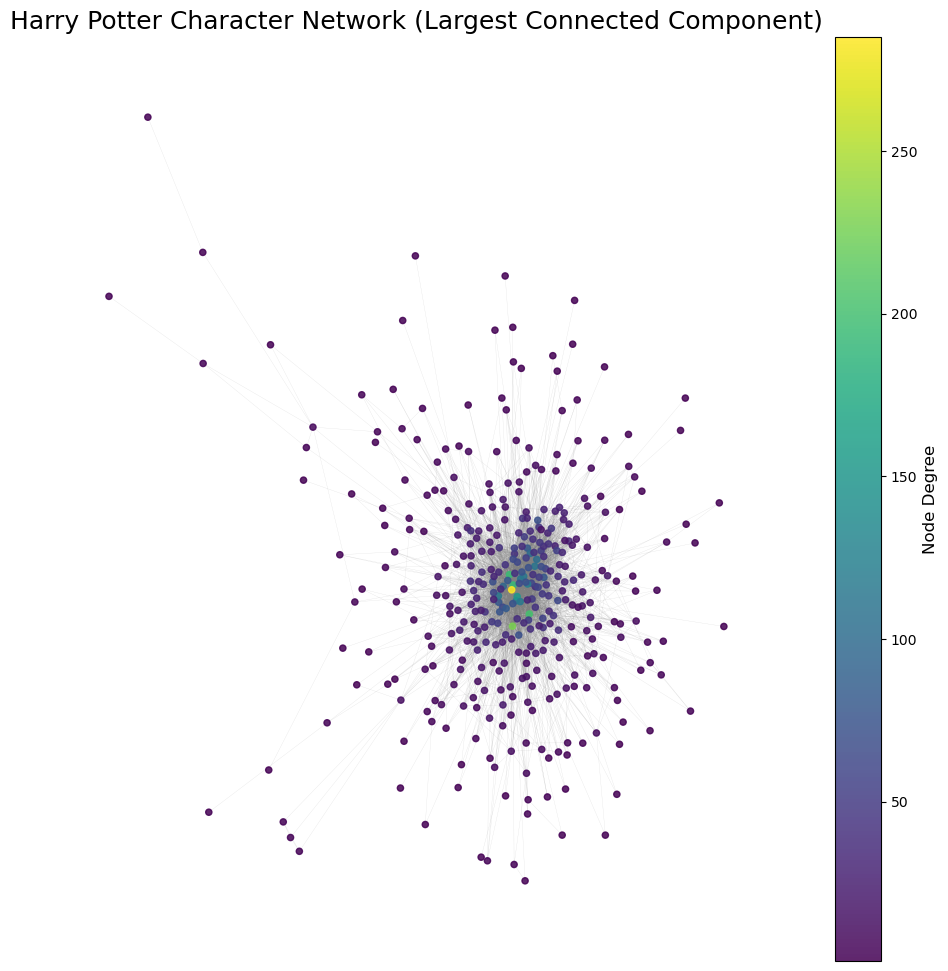

In [15]:
# 3. Network Visualization (Undirected, Degree-Colored)

import matplotlib.pyplot as plt
import networkx as nx

# Convert to undirected for visualization
G_und = HpGraph_connected.to_undirected()

# Compute node colors based on degree
degrees = dict(G_und.degree())
node_colors = [degrees[n] for n in G_und.nodes()]

# Generate spring layout
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G_und, seed=42, k=0.15)

# Draw nodes, colored by degree
nodes = nx.draw_networkx_nodes(
    G_und,
    pos,
    node_size=20,
    node_color=node_colors,
    cmap="viridis",     # beautiful scientific colormap
    alpha=0.85
)

# Draw edges
nx.draw_networkx_edges(
    G_und,
    pos,
    width=0.2,
    alpha=0.25,
    edge_color="gray"
)

# Add colorbar for degree
cbar = plt.colorbar(nodes)
cbar.set_label("Node Degree", fontsize=12)

# Title and display
plt.title("Harry Potter Character Network (Largest Connected Component)", fontsize=18)
plt.axis("off")
plt.show()


### Figure 2: Harry Potter Character Network (Largest Connected Component)

This spring-layout visualization shows the 387-node Harry Potter character network as an undirected graph, with node colors representing degree (number of connections). A higher degree corresponds to a more central or frequently connected character, as indicated by the colorbar on the right.

**Several structural patterns clearly emerge:**

A dense, brightly colored core:
* Nodes with high degree (yellow/green) cluster tightly in the center. These correspond to the main characters—Harry Potter, Dumbledore, Hermione, Ron, Voldemort—who serve as major hubs linking different parts of the network.
A large number of low-degree peripheral nodes:
* Nodes with darker colors (purple/blue) lie at the outer boundary. These correspond to minor characters who only connect to one or a few others.
Locally dense communities:
* The spring layout reveals smaller clusters branching off the main core. These clusters often correspond to families, school houses, and organizations such as the Order of the Phoenix, Death Eaters, or Hogwarts staff groups.

Overall, the visualization highlights the small-world structure observed in our quantitative analysis: a highly clustered network with a few very central hubs and many sparsely connected peripheral characters.